# 6 · Dubins paths

Shortest paths for a car that only drives forwards with a minimum turning radius — six closed-form words —
and Dubins-RRT* to plan with them among obstacles.

In [1]:
# Installs the module when it is missing (e.g. on Colab); a local `pip install -e .` is used as is.
import importlib.util

if importlib.util.find_spec("motion_planning") is None:
    %pip install -q git+https://github.com/Rudip1/learn-motion-planning

## Recap

Theory: [`1_theory/06_dubins_paths.md`](../../1_theory/06_dubins_paths.md).

- The Dubins car (6.1): unit speed, forwards only, $|\dot\theta| \le 1/\rho$ with $\rho = L/\tan\gamma_\text{max}$.
- Shortest paths are one of LSL, RSR, LSR, RSL, RLR, LRL (Dubins 1957); each has a closed form in normalised
  coordinates (6.2)–(6.8). Evaluate all six, keep the shortest.
- The Dubins distance is asymmetric and discontinuous.
- Dubins-RRT* uses Dubins paths for steering and cost, checks curves as fine polylines (6.9), and searches
  neighbours within $\gamma(\log n/n)^{1/3}$ (6.10).

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import motion_planning as mp
from motion_planning import maps
from motion_planning.plotting import INK, SERIES, mark_pose, show_grid, use_style

use_style()
rng = np.random.default_rng(6)

### ✏️ Exercise 1 — the radius of a real vehicle

The bicycle of chapter 1 has wheelbase $L = 1.2$ m and steering limit $35^\circ$. What is its minimum turning
radius $\rho$? Check it against `mp.KinematicBicycle`.

In [3]:
rho = 1.2 / np.tan(np.radians(35))

In [4]:
assert np.isclose(rho, mp.KinematicBicycle(1.2, np.radians(35)).turning_radius(np.radians(35)))
print(f"✓ rho = {rho:.3f} m")

✓ rho = 1.714 m


## The six words

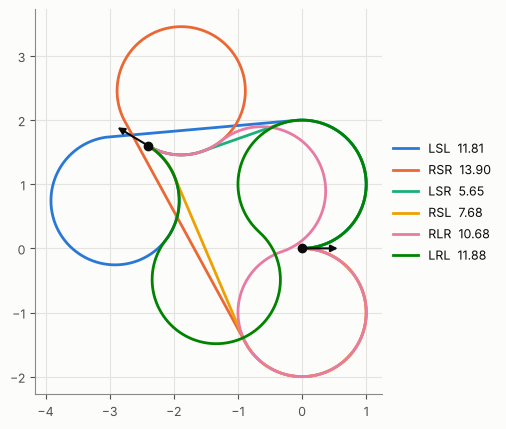

In [5]:
q0, q1 = np.zeros(3), np.array([-2.4, 1.6, 2.6])
fig, ax = plt.subplots(figsize=(7, 5))
for p, c in zip(mp.all_dubins_paths(q0, q1, 1.0), SERIES):
    s = p.sample(0.02)
    ax.plot(s[:, 0], s[:, 1], color=c, lw=2, label=f"{p.word.name}  {p.length():.2f}")
mark_pose(ax, q0, size=0.6)
mark_pose(ax, q1, size=0.6)
ax.set_aspect("equal")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

### ✏️ Exercise 2 — LSL by hand

Implement eqs. (6.2) and (6.3): return the LSL segment lengths $(t, p, q)$ in metres for poses `q0`, `q1` and
radius `rho`. (Ignore the coincident-circle case $p = 0$.)

In [6]:
def lsl(q0, q1, rho):
    dx, dy = q1[0] - q0[0], q1[1] - q0[1]
    d = np.hypot(dx, dy) / rho
    phi = np.arctan2(dy, dx)
    a, b = np.mod(q0[2] - phi, 2 * np.pi), np.mod(q1[2] - phi, 2 * np.pi)
    p2 = 2 + d**2 - 2 * np.cos(a - b) + 2 * d * (np.sin(a) - np.sin(b))
    psi = np.arctan2(np.cos(b) - np.cos(a), d + np.sin(a) - np.sin(b))
    t, q = np.mod(psi - a, 2 * np.pi), np.mod(b - psi, 2 * np.pi)
    return np.array([t, np.sqrt(p2), q]) * rho

In [7]:
for _ in range(500):
    a, b = np.r_[rng.uniform(-5, 5, 2), rng.uniform(-np.pi, np.pi)], np.r_[rng.uniform(-5, 5, 2), rng.uniform(-np.pi, np.pi)]
    r = rng.uniform(0.3, 2.0)
    assert np.allclose(lsl(a, b, r), mp.dubins_path(a, b, r, mp.DubinsWord.LSL).lengths, atol=1e-8)
print("✓ LSL")

✓ LSL


### ✏️ Exercise 3 — drive a word

Follow a Dubins path with the exact unicycle step of chapter 1 (`mp.unicycle_exact_step`, unit speed, yaw rate
$+1/\rho$, $0$ or $-1/\rho$ per segment) and return the final pose. It must equal the goal for every feasible
word.

In [8]:
TURN = {"L": 1.0, "S": 0.0, "R": -1.0}


def drive(path):
    q = np.array(path.start)
    for letter, length in zip(path.word.name, path.lengths):
        q = mp.unicycle_exact_step(q, np.array([1.0, TURN[letter] / path.radius]), length)
    return q

In [9]:
for _ in range(300):
    a, b = np.r_[rng.uniform(-4, 4, 2), rng.uniform(-np.pi, np.pi)], np.r_[rng.uniform(-4, 4, 2), rng.uniform(-np.pi, np.pi)]
    for p in mp.all_dubins_paths(a, b, 1.3):
        end = drive(p)
        assert np.allclose(end[:2], b[:2], atol=1e-8) and abs(mp.angle_difference(end[2], b[2])) < 1e-8
print("✓ every word lands on the goal")

✓ every word lands on the goal


### 🔨 Break it — `mod 2π` round-off

The quarter turn $(0, 0, 0) \to (\rho, \rho, \pi/2)$ is a single arc, length $\pi\rho/2$. In floating point some
intermediate angles come out as $-10^{-16}$ instead of 0, and `np.mod` maps that to $2\pi - 10^{-16}$: a phantom
full loop. Endpoint tests cannot see it — the loop ends where it started.

In [10]:
print("np.mod(-1e-16, 2π) =", np.mod(-1e-16, 2 * np.pi))
r = 1.5
print(f"quarter turn: expected {np.pi * r / 2:.4f}, library {mp.dubins_distance([0, 0, 0], [r, r, np.pi / 2], r):.4f}")
p_naive = lsl(np.zeros(3), np.array([r, r, np.pi / 2]), r)
print(f"your LSL (no special cases): lengths {np.round(p_naive, 4)}, total {p_naive.sum():.4f}")

np.mod(-1e-16, 2π) = 6.283185307179586
quarter turn: expected 2.3562, library 2.3562
your LSL (no special cases): lengths [4.7124 0.     7.0686], total 11.7810


### 🔨 Break it — the Dubins distance is not a metric

Measure there and back for random pairs. Using $d(\text{sample}, \text{node})$ instead of
$d(\text{node}, \text{sample})$ to pick the nearest node would extend the tree along paths it cannot drive.

In [11]:
ratios = []
for _ in range(2000):
    a, b = np.r_[rng.uniform(-3, 3, 2), rng.uniform(-np.pi, np.pi)], np.r_[rng.uniform(-3, 3, 2), rng.uniform(-np.pi, np.pi)]
    ratios.append(mp.dubins_distance(a, b, 1.0) / mp.dubins_distance(b, a, 1.0))
ratios = np.array(ratios)
print(f"d(a,b)/d(b,a): median {np.median(ratios):.2f}, 5–95 % range {np.percentile(ratios, 5):.2f}–{np.percentile(ratios, 95):.2f}")

d(a,b)/d(b,a): median 1.00, 5–95 % range 0.43–2.28


### 🔨 Break it — a point-robot path is not a car path

Take an RRT* path from chapter 5 and make a car drive through its waypoints, heading along each straight
segment: every corner turns into a Dubins detour, often a loop.

point path 8.03 m;  car through its waypoints 26.83 m, collision-free: False


Dubins-RRT*: 8.01 m, found: True


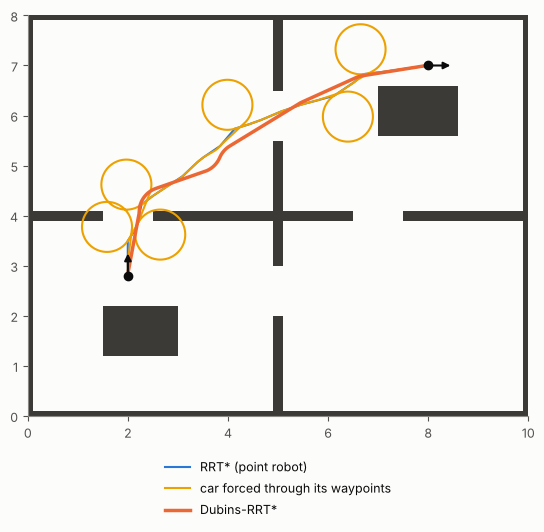

In [12]:
grid = mp.inflate(maps.rooms(), 0.25)
start, goal = np.array([2.0, 2.8, np.pi / 2]), np.array([8.0, 7.0, 0.0])
problem = mp.problem_from_grid(grid, start[:2], goal[:2])
pt = mp.rrt_star(problem, mp.RrtOptions(max_iterations=3000, step=0.5, seed=1)).path
headings = np.r_[start[2], np.arctan2(np.diff(pt[:, 1]), np.diff(pt[:, 0]))[1:], goal[2]]
poses = np.c_[pt, headings]
radius = 0.5
car = [mp.shortest_dubins_path(a, b, radius) for a, b in zip(poses[:-1], poses[1:])]
car_len = sum(p.length() for p in car)
car_ok = all(mp.dubins_path_valid(p, problem, 0.02) for p in car)
print(f"point path {mp.path_length(pt):.2f} m;  car through its waypoints {car_len:.2f} m, collision-free: {car_ok}")

dub = mp.dubins_rrt_star(problem, start, goal, mp.DubinsPlannerOptions(max_iterations=2500, radius=radius, step=2.0, seed=3))
print(f"Dubins-RRT*: {dub.path_cost:.2f} m, found: {dub.found}")

fig, ax = plt.subplots(figsize=(6.5, 5.2))
show_grid(ax, maps.rooms())
ax.plot(pt[:, 0], pt[:, 1], color=SERIES[0], lw=1.5, label="RRT* (point robot)")
s = np.vstack([p.sample(0.02) for p in car])
ax.plot(s[:, 0], s[:, 1], color=SERIES[3], lw=1.5, label="car forced through its waypoints")
d = dub.sample_path(0.02)
ax.plot(d[:, 0], d[:, 1], color=SERIES[1], lw=2.5, label="Dubins-RRT*")
mark_pose(ax, start, size=0.5)
mark_pose(ax, goal, size=0.5)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08))
plt.show()

### ✏️ Exercise 4 — how fine must curves be checked?

Using eq. (6.9), return the largest sampling step $\ell$ that keeps the chord error below `tol` for radius
`rho` (use the exact sagitta, not the bound). Then compute the error of the default step 0.05 m at radius 0.5 m.

In [13]:
def max_step(rho, tol):
    return 2 * rho * np.arccos(1 - tol / rho)


def sagitta(rho, step):
    return rho * (1 - np.cos(step / (2 * rho)))

In [14]:
assert np.isclose(sagitta(0.5, max_step(0.5, 1e-3)), 1e-3)
assert sagitta(0.5, 0.05) <= 0.05**2 / (8 * 0.5)
print(f"✓ step for 1 mm at ρ = 0.5 m: {max_step(0.5, 1e-3) * 100:.1f} cm;  error of 5 cm steps: {sagitta(0.5, 0.05) * 1e3:.3f} mm")

✓ step for 1 mm at ρ = 0.5 m: 6.3 cm;  error of 5 cm steps: 0.625 mm


### 🔨 Break it — a radius too large for the rooms

The same query with growing turning radius, three seeds each. The car must turn inside 5 m × 4 m rooms between
inflated walls; once the turning circle no longer fits, Dubins-RRT* fails within its budget — first sometimes,
then always.

In [15]:
for radius in [0.5, 1.0, 1.5, 2.0, 2.5]:
    runs = [mp.dubins_rrt_star(problem, start, goal,
                               mp.DubinsPlannerOptions(max_iterations=2500, radius=radius, step=2.0, seed=s))
            for s in (1, 2, 3)]
    found = [t for t in runs if t.found]
    best = min((t.path_cost for t in found), default=np.inf)
    print(f"ρ = {radius:3.1f} m: found in {len(found)} of 3 runs, shortest {best:.2f} m")

ρ = 0.5 m: found in 3 of 3 runs, shortest 8.01 m


ρ = 1.0 m: found in 3 of 3 runs, shortest 8.01 m


ρ = 1.5 m: found in 1 of 3 runs, shortest 8.18 m


ρ = 2.0 m: found in 1 of 3 runs, shortest 8.73 m
ρ = 2.5 m: found in 0 of 3 runs, shortest inf m


## What to remember

- A forward-only car with bounded curvature has six candidate shortest paths; evaluate them in closed form.
- Test them by driving them (chapter 1's exact flow) *and* against closed-form lengths — each test catches
  bugs the other misses.
- The Dubins distance is asymmetric and discontinuous; nearest neighbours are measured from the tree.
- Point-robot paths are not car paths; plan with the car's steering function (Dubins-RRT*) or pay with loops.
- The turning radius is a property of the vehicle (chapter 1) and decides which passages exist.